# Lecture 3: Exercise 2 - Solution

## Objective

The goal of this assignment is to perform **topic modeling** and **structured data analysis** using **Airbnb review and listing data**. You will apply **Latent Dirichlet Allocation (LDA)** to extract topics from reviews and explore structured patterns in the dataset.

## Step 1: Install and Import Required Libraries

In [ ]:
# Install required packages (uncomment if needed)
# !pip install pandas numpy gensim nltk matplotlib seaborn wordcloud pyLDAvis

In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Gensim for LDA
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from gensim.parsing.preprocessing import STOPWORDS

# NLTK for text preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries imported successfully!")

Libraries imported successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/matthiasbogaert/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/matthiasbogaert/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/matthiasbogaert/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Step 2: Load the Airbnb Data

For this example, we'll use data from **Amsterdam**. You can download it from [Inside Airbnb](http://insideairbnb.com/get-the-data.html).

In [3]:
# Load the data (adjust paths to your downloaded files)
# Download from: http://insideairbnb.com/get-the-data.html

# For this example, assume files are in the same directory
reviews = pd.read_csv('./Data/reviews.csv')
listings = pd.read_csv('./Data/listings.csv')

print(f"Loaded {len(reviews):,} reviews")
print(f"Loaded {len(listings):,} listings")

# Display first few rows
print("\n=== Reviews Sample ===")
print(reviews.head())
print("\n=== Reviews Info ===")
print(reviews.info())

Loaded 382,156 reviews
Loaded 8,533 listings

=== Reviews Sample ===
   listing_id     id        date  reviewer_id reviewer_name  \
0         958   5977  2009-07-23        15695      Edmund C   
1         958   6660  2009-08-03        26145         Simon   
2         958  11519  2009-09-27        25839         Denis   
3         958  16282  2009-11-05        33750          Anna   
4         958  26008  2010-02-13        15416       Venetia   

                                            comments  
0  Our experience was, without a doubt, a five st...  
1  Returning to San Francisco is a rejuvenating t...  
2  We were very pleased with the accommodations a...  
3  We highly recommend this accomodation and agre...  
4  Holly's place was great. It was exactly what I...  

=== Reviews Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382156 entries, 0 to 382155
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0

In [4]:
print("\n=== Listings Sample ===")
print(listings.head())
print("\n=== Listings Info ===")
print(listings.info())


=== Listings Sample ===
     id                                               name  host_id  \
0   958                Bright, Modern Garden Unit - 1BR/1B     1169   
1  3850                              Charming room for two     4921   
2  5858                                 Creative Sanctuary     8904   
3  7918         A Friendly Room - UCSF/USF - San Francisco    21994   
4  8142  Friendly Room Apt. Style -UCSF/USF - San Franc...    21994   

          host_name  neighbourhood_group     neighbourhood  latitude  \
0             Holly                  NaN  Western Addition  37.76931   
1             Kevin                  NaN      Inner Sunset  37.75402   
2  Philip And Tania                  NaN    Bernal Heights  37.74511   
3             Aaron                  NaN    Haight Ashbury  37.76669   
4             Aaron                  NaN    Haight Ashbury  37.76487   

   longitude        room_type  price  minimum_nights  number_of_reviews  \
0 -122.43386  Entire home/apt    170    

### Filter for English Reviews Only

Airbnb reviews can be written in multiple languages (French, German, Spanish, Dutch, etc.). Since our text preprocessing and analysis tools are designed for English, we need to filter out non-English reviews early in the pipeline.

This is important because:
- Topic modeling works best with a single language
- Stopwords are language-specific
- Mixed-language corpora can produce nonsensical topics
- Most NLP tools (tokenizers, stemming, etc.) are optimized for English

**Note:** Language detection is probabilistic and may occasionally misclassify very short reviews. We'll handle this by only applying detection to reviews with sufficient text.

In [20]:
from langdetect import detect, LangDetectException

def detect_language(text):
    """
    Detect the language of a text string.
    Returns language code ('en', 'fr', 'de', 'es', etc.) or None if detection fails.
    """
    try:
        if isinstance(text, str) and len(text.strip()) > 10:  # Only detect for texts > 10 chars
            return detect(text)
        return None
    except LangDetectException:
        return None

# First, remove reviews without comments
print(f"Initial reviews: {len(reviews):,}")
reviews_filtered = reviews.dropna(subset=['comments']).copy()
print(f"Reviews with comments: {len(reviews_filtered):,}")

# Detect language for each review
print("\nDetecting language for each review (this may take a moment)...")
reviews_filtered['detected_lang'] = reviews_filtered['comments'].apply(detect_language)

# Check language distribution
print("\nLanguage distribution in reviews:")
lang_counts = reviews_filtered['detected_lang'].value_counts()
print(lang_counts.head(10))

# Calculate percentages
total_with_lang = reviews_filtered['detected_lang'].notna().sum()
print(f"\nTotal reviews with detected language: {total_with_lang:,}")
if 'en' in lang_counts.index:
    en_percentage = (lang_counts['en'] / total_with_lang) * 100
    print(f"English reviews: {lang_counts['en']:,} ({en_percentage:.1f}%)")

# Filter for English only
initial_count = len(reviews_filtered)
reviews_english = reviews_filtered[reviews_filtered['detected_lang'] == 'en'].copy()
reviews_english = reviews_english.drop('detected_lang', axis=1).reset_index(drop=True)

print(f"\n{'='*60}")
print(f"Filtering Results:")
print(f"  Before language filtering: {initial_count:,} reviews")
print(f"  After filtering (English only): {len(reviews_english):,} reviews")
print(f"  Removed: {initial_count - len(reviews_english):,} non-English reviews ({(1 - len(reviews_english)/initial_count)*100:.1f}%)")
print(f"{'='*60}")

# Update reviews variable to use filtered version
reviews = reviews_english
print(f"\n✓ Proceeding with {len(reviews):,} English reviews")

Initial reviews: 382,156
Reviews with comments: 382,021

Detecting language for each review (this may take a moment)...

Language distribution in reviews:
detected_lang
en       354354
fr         7721
de         4552
es         3416
zh-cn      2274
ko         1737
it          834
pt          614
ro          614
nl          609
Name: count, dtype: int64

Total reviews with detected language: 378,934
English reviews: 354,354 (93.5%)

Filtering Results:
  Before language filtering: 382,021 reviews
  After filtering (English only): 354,354 reviews
  Removed: 27,667 non-English reviews (7.2%)

✓ Proceeding with 354,354 English reviews


## Step 3: Preprocess the Review Text

We perform comprehensive text preprocessing to prepare reviews for topic modeling. The preprocessing includes:

1. **Basic cleaning**: Lowercase conversion, removal of URLs, emails, and numbers
2. **Punctuation removal**: Removes all special characters
3. **Tokenization**: Splits text into individual words
4. **Standard stopword removal**: Removes common English words (the, is, at, etc.)
5. **Domain-specific stopword removal**: Removes Airbnb-specific terms that appear frequently but don't contribute meaningful semantic content for topic modeling:
   - `airbnb`, `stayed`, `stay`: Generic platform/action terms
   - `host`, `apartment`, `place`, `room`: Overly general location terms
   
   These domain-specific stopwords are crucial because they appear in almost every review but don't help distinguish between topics. Removing them allows more meaningful content words to emerge in the topic models.
6. **Short word filtering**: Removes words with 2 or fewer characters

This preprocessing ensures that the LDA model focuses on meaningful content words that reveal distinct topics in the reviews.

In [21]:
# Remove reviews without comments
reviews_clean = reviews.dropna(subset=['comments']).copy()
print(f"Reviews with comments: {len(reviews_clean):,}")

# Define preprocessing function
def preprocess_text(text):
    """
    Preprocess text for topic modeling:
    - Lowercase
    - Remove URLs, emails, numbers
    - Remove punctuation
    - Tokenize
    - Remove stopwords and short words
    """
    if not isinstance(text, str):
        return []
    
    # Lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords and short words
    stop_words = set(stopwords.words('english'))
    # Add domain-specific stopwords
    stop_words.update(['airbnb', 'stayed', 'stay', 'host', 'apartment', 'place', 'room'])
    
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    return tokens

# Apply preprocessing
print("Preprocessing reviews (this may take a moment)...")
reviews_clean['tokens'] = reviews_clean['comments'].apply(preprocess_text)

# Remove empty documents
reviews_clean = reviews_clean[reviews_clean['tokens'].apply(len) > 0].copy()

print(f"Reviews after preprocessing: {len(reviews_clean):,}")
print(f"\nExample tokenized review:")
print(reviews_clean['tokens'].iloc[0][:20])

Reviews with comments: 354,354
Preprocessing reviews (this may take a moment)...
Reviews after preprocessing: 354,326

Example tokenized review:
['experience', 'without', 'doubt', 'five', 'star', 'experience', 'holly', 'husband', 'david', 'consummate', 'hosts', 'friendly', 'accomodating', 'still', 'honoring', 'privacy', 'charming', 'layout', 'full', 'view']


## Step 4: Create Document-Term Matrix

In [22]:
# Extract tokens
tokenized_docs = reviews_clean['tokens'].tolist()

# Create dictionary
dictionary = corpora.Dictionary(tokenized_docs)

print(f"Original vocabulary size: {len(dictionary)}")

# Filter extremes: remove words that appear in less than 5 documents or more than 50% of documents
dictionary.filter_extremes(no_below=5, no_above=0.5)

print(f"Filtered vocabulary size: {len(dictionary)}")

# Create corpus (bag of words)
corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]

print(f"Corpus size: {len(corpus)} documents")
print(f"\nExample document (first 10 words):")
print(corpus[0][:10])

Original vocabulary size: 81475
Filtered vocabulary size: 19077
Corpus size: 354326 documents

Example document (first 10 words):
[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1)]


## Step 5: Determine Optimal Number of Topics

Running this code can take a long time (30 minutes on my system). Hence, a practical approach to reduce training time can be to:

1. **Take a random subsample** e.g., 10-20% of documents
2. **Determine the optimal number of topics** using the subsample
3. **Train the final model** on the full dataset with the selected number of topics
4. **Apply the trained model** to get topic distributions for all documents

This approach can reduce computation time by 80-90% while still providing reliable topic number selection, since the optimal number of topics is typically consistent across subsamples of sufficient size.

**Implementation example:**
```python
# Create subsample for topic selection (20% of data)
sample_size = int(len(tokenized_docs) * 0.2)
sample_indices = np.random.choice(len(tokenized_docs), sample_size, replace=False)
tokenized_docs_sample = [tokenized_docs[i] for i in sample_indices]
corpus_sample = [corpus[i] for i in sample_indices]

# Use corpus_sample and tokenized_docs_sample for testing
# Then use full corpus and tokenized_docs for final model training
```

For this exercise, we'll use the full dataset, but feel free to change the code if needed!

In [23]:
# Test different numbers of topics
print("Testing different numbers of topics...")
print("This may take several minutes...")

coherence_scores = []
aic_scores = []
topic_range = range(2, 11)

for num_topics in topic_range:
    print(f"Training model with {num_topics} topics...")
    
    # Train LDA model
    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=10,
        alpha='auto',
        per_word_topics=True
    )
    
    # Calculate coherence score (u_mass)
    coherence_model = CoherenceModel(
        model=lda,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='u_mass'
    )
    coherence = coherence_model.get_coherence()
    coherence_scores.append(coherence)
    
    # Calculate AIC (Akaike Information Criterion)
    # AIC = -2 * log_likelihood + 2 * k
    # where k is the number of parameters
    log_likelihood = lda.bound(corpus)
    num_params = num_topics * len(dictionary) + num_topics  # topic-word + topic distributions
    aic = -2 * log_likelihood + 2 * num_params
    aic_scores.append(aic)
    
    print(f"  Coherence (c_umass): {coherence:.4f}, AIC: {aic:.2f}")

print("\nDone!")

Testing different numbers of topics...
This may take several minutes...
Training model with 2 topics...
  Coherence (c_umass): -2.0595, AIC: 123004675.31
Training model with 3 topics...
  Coherence (c_umass): -2.1269, AIC: 122829818.79
Training model with 4 topics...
  Coherence (c_umass): -2.2117, AIC: 122867065.01
Training model with 5 topics...
  Coherence (c_umass): -2.7399, AIC: 123248502.66
Training model with 6 topics...
  Coherence (c_umass): -2.7809, AIC: 123728195.25
Training model with 7 topics...
  Coherence (c_umass): -2.9819, AIC: 124225280.40
Training model with 8 topics...
  Coherence (c_umass): -3.0139, AIC: 125188111.52
Training model with 9 topics...
  Coherence (c_umass): -3.7352, AIC: 126688461.24
Training model with 10 topics...
  Coherence (c_umass): -3.3215, AIC: 129147627.67

Done!


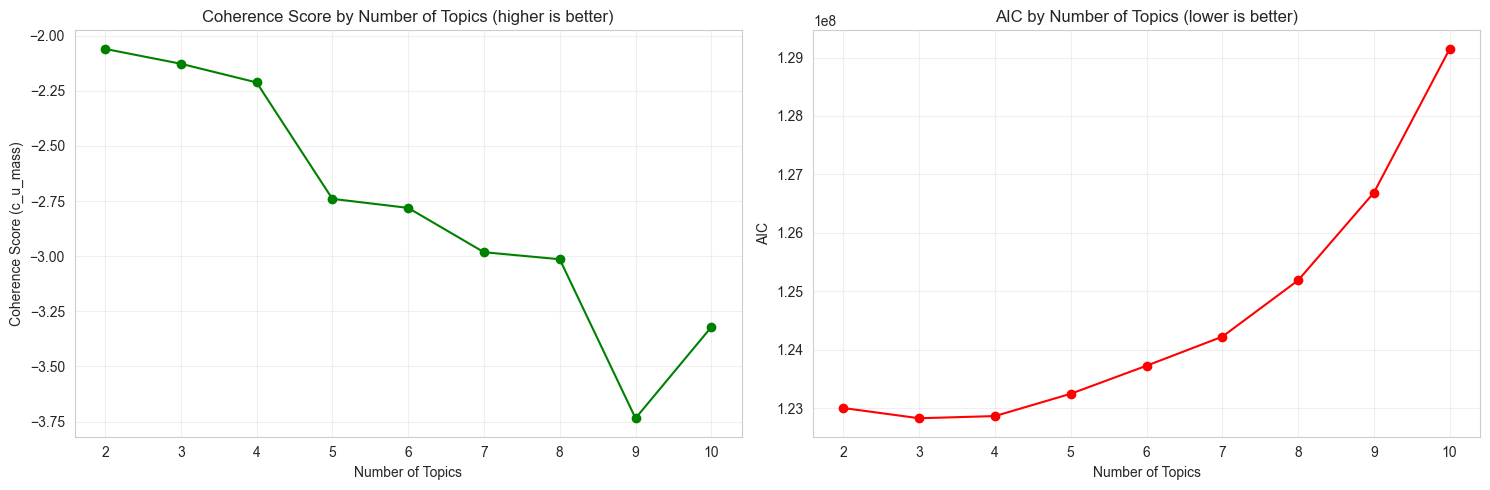


Optimal number of topics (based on u_mass coherence): 2
  Coherence score: -2.0595

Optimal number of topics (based on AIC): 3
  AIC score: 122829818.79


In [24]:
# Plot coherence scores and AIC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot coherence (c_u_mass): higher is better
ax1.plot(topic_range, coherence_scores, marker='o', color='green')
ax1.set_xlabel('Number of Topics')
ax1.set_ylabel('Coherence Score (c_u_mass)')
ax1.set_title('Coherence Score by Number of Topics (higher is better)')
ax1.grid(True, alpha=0.3)

# Plot AIC: lower is better
ax2.plot(topic_range, aic_scores, marker='o', color='red')
ax2.set_xlabel('Number of Topics')
ax2.set_ylabel('AIC')
ax2.set_title('AIC by Number of Topics (lower is better)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Select optimal number of topics
# For u_mass: higher is better (maximize)
optimal_topics_coherence = topic_range[np.argmax(coherence_scores)]
# For AIC: lower is better (minimize)
optimal_topics_aic = topic_range[np.argmin(aic_scores)]

print(f"\nOptimal number of topics (based on u_mass coherence): {optimal_topics_coherence}")
print(f"  Coherence score: {max(coherence_scores):.4f}")
print(f"\nOptimal number of topics (based on AIC): {optimal_topics_aic}")
print(f"  AIC score: {min(aic_scores):.2f}")

## Step 6: Train Final LDA Model

In [25]:
# Train final LDA model with optimal number of topics
print(f"Training final LDA model with {optimal_topics_coherence} topics...")

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=optimal_topics_coherence,
    random_state=42,
    passes=15,
    iterations=400,
    alpha='auto',
    eta='auto',
    per_word_topics=True
)

print("Model trained successfully!")
print(f"\nModel info:")
print(f"Number of topics: {lda_model.num_topics}")
print(f"Number of terms: {len(dictionary)}")

Training final LDA model with 2 topics...
Model trained successfully!

Model info:
Number of topics: 2
Number of terms: 19077


## Step 7: Interpret Topics

In [ ]:
# Display top words for each topicn
topic_words = []
for i in range(lda_model.num_topics):
    words = [word for word, _ in lda_model.show_topic(i, topn=10)]
    topic_words.append(words)
    
print("\n" + "=" * 80)
print("TOPIC SUMMARY (Top 10 Words)")
print("=" * 80)
for i, words in enumerate(topic_words):
    print(f"\nTopic {i}: {', '.join(words)}")


TOPIC SUMMARY (Top 10 Words)

Topic 0: parking, bathroom, kitchen, walk, street, park, also, one, bed, get

Topic 1: great, clean, location, would, nice, comfortable, recommend, easy, everything, san


### Visualize Topics with Bar Charts

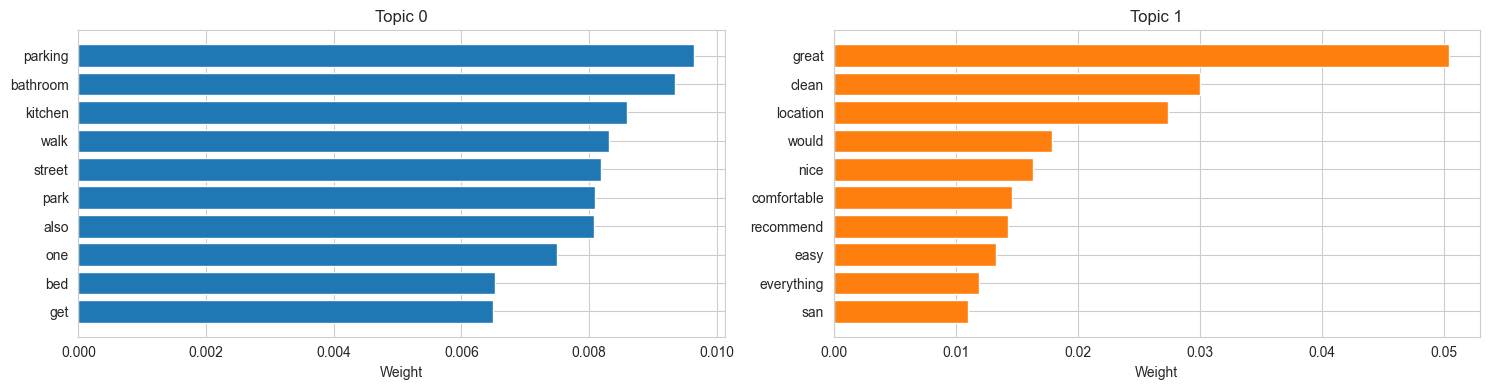

In [28]:
# Create bar charts for each topic
n_topics = lda_model.num_topics
n_cols = 2
n_rows = (n_topics + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for topic_id in range(n_topics):
    # Get top words and their weights
    topic_data = lda_model.show_topic(topic_id, topn=10)
    words = [word for word, _ in topic_data]
    weights = [weight for _, weight in topic_data]
    
    # Plot
    ax = axes[topic_id]
    ax.barh(words, weights, color=plt.cm.tab10(topic_id % 10))
    ax.set_xlabel('Weight')
    ax.set_title(f'Topic {topic_id}')
    ax.invert_yaxis()

# Hide extra subplots if odd number of topics
for i in range(n_topics, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Visualize Topics with Word Clouds

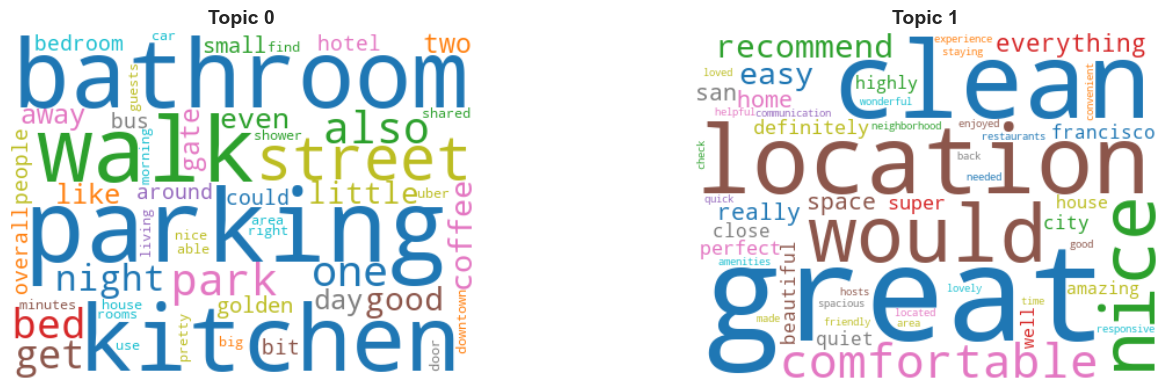

In [29]:
# Create word clouds for each topic
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for topic_id in range(n_topics):
    # Get topic words and weights
    topic_dict = dict(lda_model.show_topic(topic_id, topn=50))
    
    # Create word cloud
    wc = WordCloud(
        width=400,
        height=300,
        background_color='white',
        colormap=plt.cm.tab10.name,
        relative_scaling=0.5,
        random_state=42
    ).generate_from_frequencies(topic_dict)
    
    # Plot
    ax = axes[topic_id]
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Topic {topic_id}', fontsize=14, fontweight='bold')
    ax.axis('off')

# Hide extra subplots
for i in range(n_topics, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Step 8: Assign Topics to Documents

In [30]:
# Get dominant topic for each document
def get_dominant_topic(ldamodel, corpus):
    """Get the dominant topic for each document"""
    dominant_topics = []
    topic_percentages = []
    
    for i, doc in enumerate(corpus):
        # Get topic distribution for document
        topic_dist = ldamodel.get_document_topics(doc)
        
        # Find dominant topic
        if topic_dist:
            dominant_topic = sorted(topic_dist, key=lambda x: x[1], reverse=True)[0]
            dominant_topics.append(dominant_topic[0])
            topic_percentages.append(dominant_topic[1])
        else:
            dominant_topics.append(-1)
            topic_percentages.append(0.0)
    
    return dominant_topics, topic_percentages

# Get dominant topics
dominant_topics, topic_percentages = get_dominant_topic(lda_model, corpus)

# Add to dataframe
reviews_clean['dominant_topic'] = dominant_topics
reviews_clean['topic_percentage'] = topic_percentages

print(f"Documents assigned to topics!")
print(f"\nTopic distribution:")
print(reviews_clean['dominant_topic'].value_counts().sort_index())

Documents assigned to topics!

Topic distribution:
dominant_topic
0     55924
1    298402
Name: count, dtype: int64


In [34]:
# Display sample reviews for each topic
print("=" * 80)
print("SAMPLE REVIEWS PER TOPIC")
print("=" * 80)

for topic_id in range(lda_model.num_topics):
    print(f"\n{'=' * 80}")
    print(f"TOPIC {topic_id}")
    print(f"Top words: {', '.join([word for word, _ in lda_model.show_topic(topic_id, topn=5)])}")
    print(f"{'=' * 80}")
    
    # Get sample reviews for this topic
    topic_reviews = reviews_clean[reviews_clean['dominant_topic'] == topic_id]['comments'].head(3)
    
    for i, review in enumerate(topic_reviews, 1):
        print(f"\nReview {i}:")
        print(review[:300] + "..." if len(review) > 300 else review)

SAMPLE REVIEWS PER TOPIC

TOPIC 0
Top words: parking, bathroom, kitchen, walk, street

Review 1:
We were very pleased with the accommodations and the friendly neighborhood. Being able to make a second bed out of the futon couch was particularly helpful. Having a full kitchen, a lovely walkout garden, and TV + DVD + FM stereo were added bonuses. Holly and David were most gracious and met our eve...

Review 2:
We highly recommend this accomodation and agree with the previous postings: Holly and David were extremely helpful and friendly (but not at all instrusive), the unit itself is just superb and in a wondeful location. Unlike some other Airbnb accomodation optins, this is a dedicated rental unit, furni...

Review 3:
On top of all that has been said previously, I would add that it is a very quiet place. Holly and David are very nice and accomodating. Staying with our 19-month old boy was not a problem, only a few items had to be moved out of reach - enquire if you have special needs fo

## Step 9: Extended Analysis - Neighborhood Patterns

Let's merge with the listings data to analyze topics by neighborhood.

In [31]:
# Check available columns in listings dataframe
print("Available columns in listings:")
print(listings.columns.tolist())
print(f"\nTotal columns: {len(listings.columns)}")

Available columns in listings:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Total columns: 16


Using columns: ['id', 'neighbourhood', 'room_type', 'price']

Merged 354,326 reviews with listing information

=== Topic Distribution by Neighborhood (Top 10 Neighborhoods) ===


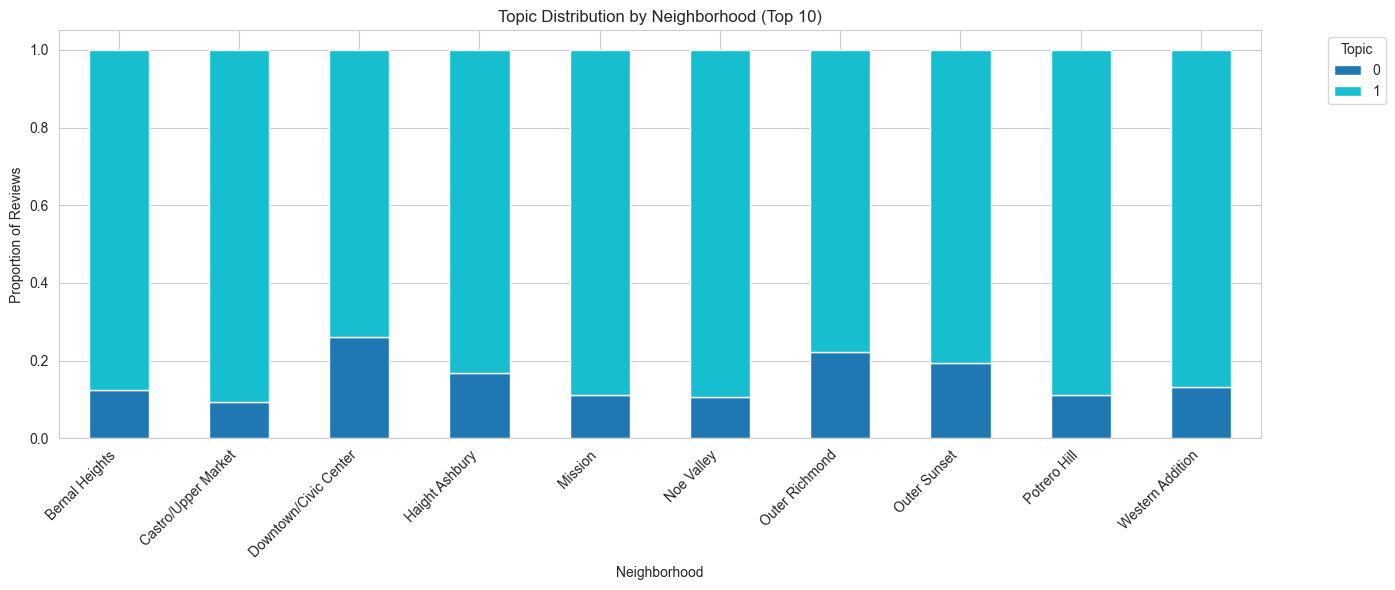


Topic distribution (proportions):
dominant_topic                0         1
neighbourhood                            
Bernal Heights         0.124500  0.875500
Castro/Upper Market    0.092770  0.907230
Downtown/Civic Center  0.261081  0.738919
Haight Ashbury         0.167401  0.832599
Mission                0.110637  0.889363
Noe Valley             0.106544  0.893456
Outer Richmond         0.221977  0.778023
Outer Sunset           0.194989  0.805011
Potrero Hill           0.112385  0.887615
Western Addition       0.132457  0.867543


In [32]:
# Merge reviews with listings to get neighborhood information
# Select only columns that exist in the listings dataframe
available_columns = ['id']
optional_columns = ['neighbourhood_cleansed', 'neighbourhood', 'room_type', 'price']

# Check which optional columns exist
for col in optional_columns:
    if col in listings.columns:
        available_columns.append(col)
    else:
        print(f"Warning: Column '{col}' not found in listings dataframe")

print(f"Using columns: {available_columns}")

reviews_with_listings = reviews_clean.merge(
    listings[available_columns],
    left_on='listing_id',
    right_on='id',
    how='left'
)

print(f"\nMerged {len(reviews_with_listings):,} reviews with listing information")

# Determine which neighborhood column to use
neighborhood_col = 'neighbourhood_cleansed' if 'neighbourhood_cleansed' in available_columns else 'neighbourhood'

# Check if we have the necessary columns for analysis
if neighborhood_col in reviews_with_listings.columns:
    # Analyze topic distribution by neighborhood
    print(f"\n=== Topic Distribution by Neighborhood (Top 10 Neighborhoods) ===")
    
    # Get top neighborhoods by review count
    top_neighborhoods = reviews_with_listings[neighborhood_col].value_counts().head(10).index
    
    # Create crosstab
    neighborhood_topics = pd.crosstab(
        reviews_with_listings[reviews_with_listings[neighborhood_col].isin(top_neighborhoods)][neighborhood_col],
        reviews_with_listings[reviews_with_listings[neighborhood_col].isin(top_neighborhoods)]['dominant_topic'],
        normalize='index'
    )
    
    # Plot
    neighborhood_topics.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab10')
    plt.title('Topic Distribution by Neighborhood (Top 10)')
    plt.xlabel('Neighborhood')
    plt.ylabel('Proportion of Reviews')
    plt.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    print("\nTopic distribution (proportions):")
    print(neighborhood_topics)
else:
    print("\nSkipping neighborhood analysis - neighborhood column not available in listings data")

### Extended Analysis - Room Type Comparison

=== Topic Distribution by Room Type ===


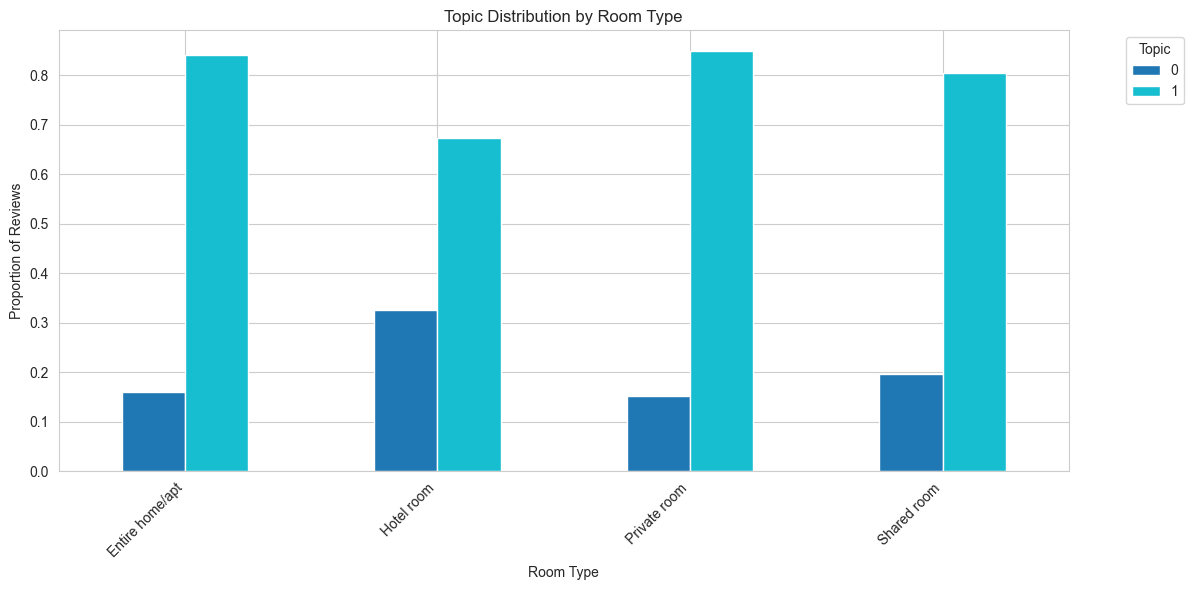


Topic distribution by room type:
dominant_topic          0         1
room_type                          
Entire home/apt  0.159552  0.840448
Hotel room       0.325986  0.674014
Private room     0.152097  0.847903
Shared room      0.196536  0.803464


In [33]:
# Analyze topic distribution by room type
print("=== Topic Distribution by Room Type ===")

room_type_topics = pd.crosstab(
    reviews_with_listings['room_type'],
    reviews_with_listings['dominant_topic'],
    normalize='index'
)

# Plot
room_type_topics.plot(kind='bar', figsize=(12, 6), colormap='tab10')
plt.title('Topic Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Proportion of Reviews')
plt.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTopic distribution by room type:")
print(room_type_topics)

## Summary and Insights

### Key Insights

Based on the LDA topic modeling analysis of Airbnb reviews, we discovered distinct topics that represent different aspects of the guest experience. Let's examine the two main topics in detail:

**Topic 0: Physical features and practicalities of the amenity**

**Top words:** parking, bathroom, kitchen, walk, street, park, also, one, bed, get

This topic captures reviews focused on **concrete, practical aspects** of the property:

- Heavy emphasis on specific facilities (kitchen, bathroom, parking)
- Mentions of beds, rooms, and physical arrangements (e.g., "futon couch", "walkout garden")
- Parking availability, street access, proximity to parks
- Reviews tend to be longer and more detailed, listing specific features
- References to accommodating children, space for families, safety features

**Topic 1: Overall experience and location**

**Top words:** great, clean, location, would, nice, comfortable, recommend, easy, everything, san

This topic captures reviews focused on **evaluative assessments** and **overall satisfaction**:

- Dominated by positive adjectives (great, nice, comfortable)
- Strong focus on San Francisco location and accessibility
- **Brevity:** Reviews tend to be shorter, more enthusiastic summaries
- "Clean" is a top word, indicating importance to this segment

### Business Implications:

1. **For hosts:**
   - **Topic 0 dominance:** Invest in quality amenities (kitchen, parking, comfortable beds)
   - **Topic 1 dominance:** Focus on location advantages, cleanliness, and guest experience
   - Optimize listings to address both practical features and experience 
   - Different topics may dominate in different neighborhoods or property types

2. **For Airbnb:**
   - Use topic analysis to match guests with appropriate properties
   - Identify successful property features by neighborhood
   - Develop targeted search filters based on topic preferences
   - Understand market segments (amenity-seekers vs. experience-seekers)

3. **For guests:**
   - Reviews dominated by Topic 0: Good for families, longer stays, self-catering
   - Reviews dominated by Topic 1: Good for short visits, tourists, location-focused travelers
   - Better understanding of what aspects matter to previous guests

### Limitations:

- Topic interpretation is subjective and context-dependent
- Results depend on preprocessing choices (stopwords, filtering)
- Some topics may overlap (e.g., cleanliness appears in multiple contexts)
- Optimal number of topics varies by dataset size and domain
- Language filtering affects topic quality (we filtered for English only)